Dataset Shape: (167, 10)
               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  


D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

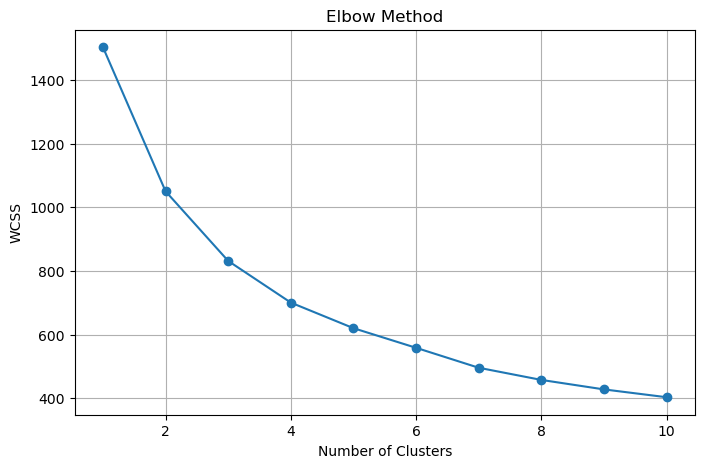

D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


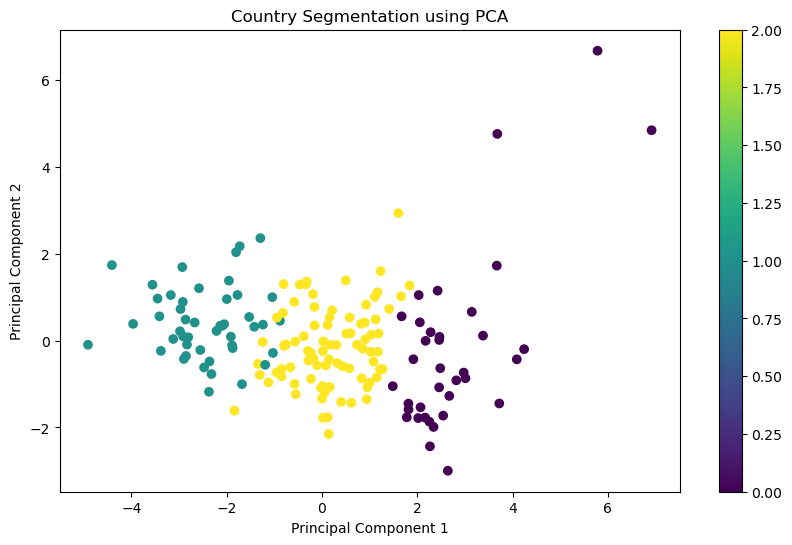


Cluster Summary
         child_mort    exports    health    imports        income  inflation  \
Cluster                                                                        
0          5.000000  58.738889  8.807778  51.491667  45672.222222   2.671250   
1         92.961702  29.151277  6.388511  42.323404   3942.404255  12.019681   
2         21.927381  40.243917  6.200952  47.473404  12305.595238   7.600905   

         life_expec  total_fer          gdpp  
Cluster                                       
0         80.127778   1.752778  42494.444444  
1         59.187234   5.008085   1922.382979  
2         72.814286   2.307500   6486.452381  

Needy Cluster: 1

Countries Requiring Aid:

Afghanistan
Angola
Benin
Botswana
Burkina Faso
Burundi
Cameroon
Central African Republic
Chad
Comoros
Congo, Dem. Rep.
Congo, Rep.
Cote d'Ivoire
Equatorial Guinea
Eritrea
Gabon
Gambia
Ghana
Guinea
Guinea-Bissau
Haiti
Iraq
Kenya
Kiribati
Lao
Lesotho
Liberia
Madagascar
Malawi
Mali
Mauritania
Mozambique


In [3]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("Country-data.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# ==========================================
# Separate Country Names
# ==========================================

countries = df["country"]

# Features only
X = df.drop("country", axis=1)

# ==========================================
# Feature Scaling
# ==========================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# Elbow Method
# ==========================================

wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

# ==========================================
# KMeans Clustering
# ==========================================

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

# ==========================================
# PCA Visualization
# ==========================================

pca = PCA(n_components=2)

pca_result = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    pca_result[:,0],
    pca_result[:,1],
    c=df["Cluster"]
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Country Segmentation using PCA")
plt.colorbar(scatter)
plt.show()

# ==========================================
# Cluster Summary
# ==========================================

cluster_summary = df.groupby("Cluster").mean(
    numeric_only=True
)

print("\nCluster Summary")
print(cluster_summary)

# ==========================================
# Determine Needy Cluster
# Lowest GDP = Most Underdeveloped
# ==========================================

needy_cluster = cluster_summary["gdpp"].idxmin()

print("\nNeedy Cluster:", needy_cluster)

# ==========================================
# Countries Requiring Aid
# ==========================================

needy_countries = df[
    df["Cluster"] == needy_cluster
]["country"]

print("\nCountries Requiring Aid:\n")

for country in needy_countries:
    print(country)

# ==========================================
# Display Countries by Cluster
# ==========================================

for cluster in sorted(df["Cluster"].unique()):

    print(f"\n{'='*50}")
    print(f"Cluster {cluster}")
    print(f"{'='*50}")

    countries = df[
        df["Cluster"] == cluster
    ]["country"].tolist()

    print(countries)

# ==========================================
# Save Output
# ==========================================

df.to_csv(
    "Country_Development_Analysis_Output.csv",
    index=False
)

print(
    "\nResults saved to "
    "Country_Development_Analysis_Output.csv"
)